# Regresión — Predicción del Puntaje Global Saber 11 en Córdoba

**Pregunta de negocio:** ¿Es posible predecir el puntaje global que obtendrá un estudiante de Córdoba en el Saber 11 a partir de su contexto familiar y características de su colegio, antes de presentar la prueba?

**Tipo de problema:** Regresión (variable objetivo continua: `punt_global`).

**Cliente:** Secretaría de Educación de Córdoba.

**Uso del modelo:** Identificar estudiantes y colegios con alto riesgo de puntaje bajo para focalizar recursos de acompañamiento académico antes de la prueba.

**Métricas clave:**
- **RMSE** (Root Mean Squared Error): penaliza errores grandes.
- **MAE** (Mean Absolute Error): interpretable en unidades del puntaje.
- **R²** (coeficiente de determinación): proporción de varianza explicada.

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn tensorflow mlflow

  Obtaining dependency information for mlflow from https://files.pythonhosted.org/packages/7e/f8/47f28975c1c1b70d351fa19c5aef21cef5ae1e1aca36bd1858798384bdbb/mlflow-3.12.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/49.2 kB ? eta -:--:--
     -------- ------------------------------- 10.2/49.2 kB ? eta -:--:--
     ----------------------- -------------- 30.7/49.2 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 49.2/49.2 kB 414.6 kB/s eta 0:00:00
  Obtaining dependency information for mlflow-skinny==3.12.0 from https://files.pythonhosted.org/packages/95/05/2df60fab37881c490e9364ea697a6c3a78d3b593fde2d9332a75f8cdf1f8/mlflow_skinny-3.12.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/50.0 kB ? eta -:--:--
     ---------------------------------------- 50.0/50.0 kB 2.5 MB/s eta 0:00:00
  Obtaining dependency information for mlflow-tracing==3.12.0 from https://files.pythonhosted.org/packages/a5/bf/e22b778addbe


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuración del entorno y MLflow

Cargamos las librerías necesarias y configuramos MLflow para registrar todos los experimentos en la carpeta local `mlruns/`. Esto cumple con el requisito del proyecto de documentar el modelamiento con MLflow.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mlflow
import mlflow.keras
import mlflow.sklearn

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Saber11_Cordoba_PuntajeGlobal_Regresion")

print("Librerías cargadas correctamente.")
print("TensorFlow versión:", tf.__version__)

c:\Users\abrah\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\abrah\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/12 16:34:02 INFO mlflow.tracking.fluent: Experiment with name 'Saber11_Cordoba_PuntajeGlobal_Regresion' does not exist. Creating a new experiment.


Librerías cargadas correctamente.
TensorFlow versión: 2.20.0


## 2. Carga de datos

Usamos los datos limpios de la Tarea 2 (`Resultados_ICFES_Cordoba_clean.csv`). El dataset contiene los resultados de la prueba Saber 11 para estudiantes del departamento de Córdoba.

In [3]:
df = pd.read_csv("../Resultados_ICFES_Cordoba_clean.csv")
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")

punt_cols = [c for c in df.columns if c.startswith("punt_")]
print("\nColumnas de puntaje disponibles:")
print(df[punt_cols].describe().round(2))
df.head()

Filas: 194,259  |  Columnas: 51

Columnas de puntaje disponibles:
       punt_ingles  punt_matematicas  punt_sociales_ciudadanas  \
count    194088.00         194259.00                 118523.00   
mean         45.64             46.60                     46.81   
std           9.98             11.11                     11.02   
min          -1.00              0.00                      0.00   
25%          39.00             39.00                     39.00   
50%          44.00             46.00                     46.00   
75%          50.00             53.16                     54.00   
max         117.29            116.00                    100.00   

       punt_c_naturales  punt_lectura_critica  punt_global  
count         118523.00             118523.00    118523.00  
mean              48.72                 49.57       240.98  
std                9.88                  9.80        46.01  
min                0.00                  0.00         0.00  
25%               42.00           

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,TI,SB11202240331749,URBANO,N,A,ACADÉMICO,1.230900e+11,123090000301,23,...,NO,NO,SI,A-,43.0,50.0,42.0,46.0,52.0,236.0
1,20224,TI,SB11202240555914,RURAL,N,A,ACADÉMICO,2.231620e+11,223162001662,23,...,NO,NO,SI,A2,59.0,54.0,51.0,57.0,49.0,266.0
2,20224,TI,SB11202240559153,RURAL,NaN,A,NO APLICA,2.236700e+11,223670000507,23,...,NO,NO,NO,A-,34.0,37.0,28.0,36.0,41.0,177.0
3,20224,TI,SB11202240526915,RURAL,NaN,A,ACADÉMICO,2.236600e+11,223660001084,23,...,NaN,NaN,NaN,A-,41.0,63.0,63.0,58.0,60.0,297.0
4,20224,TI,SB11202240311533,URBANO,N,A,ACADÉMICO,3.230010e+11,323001004178,23,...,SI,SI,SI,A1,56.0,72.0,52.0,59.0,65.0,308.0


## 3. Definición de la variable objetivo

La variable objetivo es `punt_global`, el puntaje global del estudiante en el Saber 11 (suma ponderada de los cinco componentes). Su rango es aproximadamente 0–500, con media ~241 y desviación estándar ~46.

**Nota sobre nulos en `punt_global`:** Aproximadamente el 39% de las filas no tienen `punt_global` registrado. Esto se debe a que el ICFES solo publica el puntaje global para los períodos más recientes del formato vigente (a partir de 2022). Filtramos únicamente las filas con puntaje global disponible (~118 K estudiantes), lo que sigue siendo un conjunto amplio y representativo.

**Importante — data leakage:** Los demás puntajes individuales (`punt_ingles`, `punt_matematicas`, etc.) son **componentes** del puntaje global, por lo que **no se incluyen como features**. Solo se usan variables disponibles *antes* de presentar la prueba.

Filas con punt_global disponible: 118,523
Filas descartadas (sin punt_global): 75,736

Distribución de punt_global:
count    118523.00
mean        240.98
std          46.01
min           0.00
25%         207.00
50%         235.00
75%         270.00
max         471.00
Name: punt_global, dtype: float64


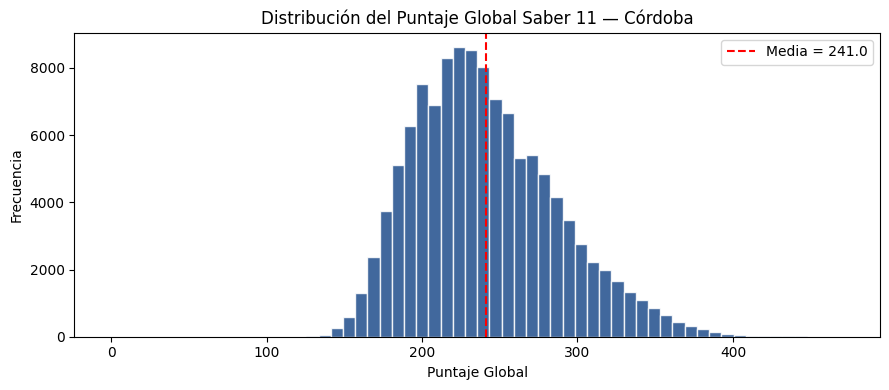

In [4]:
df_reg = df.dropna(subset=["punt_global"]).copy()
print(f"Filas con punt_global disponible: {df_reg.shape[0]:,}")
print(f"Filas descartadas (sin punt_global): {df.shape[0] - df_reg.shape[0]:,}")

print("\nDistribución de punt_global:")
print(df_reg["punt_global"].describe().round(2))

plt.figure(figsize=(9, 4))
plt.hist(df_reg["punt_global"], bins=60, color="#1f4e8c", edgecolor="white", alpha=0.85)
plt.axvline(df_reg["punt_global"].mean(), color="red", linestyle="--",
            label=f"Media = {df_reg['punt_global'].mean():.1f}")
plt.xlabel("Puntaje Global"); plt.ylabel("Frecuencia")
plt.title("Distribución del Puntaje Global Saber 11 — Córdoba")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Selección y justificación de variables

Solo se incluyen variables disponibles **antes** de presentar la prueba. Se excluyen todos los puntajes individuales (`punt_*`), identificadores, fechas crudas y el desempeño en inglés.

### Variables del colegio (institucional)
- `cole_area_ubicacion` — Urbano/Rural. La brecha urbano-rural en educación es bien documentada.
- `cole_naturaleza` — Oficial / No oficial. Indicador de recursos institucionales.
- `cole_jornada` — Mañana, tarde, noche, completa, única. Tiempo lectivo disponible.
- `cole_calendario` — A / B. Tipo de calendario académico.
- `cole_caracter` — Académico, técnico, etc.
- `cole_bilingue` — Si el colegio es bilingüe.
- `cole_genero` — Mixto, masculino, femenino.

### Variables familiares (socioeconómicas)
- `fami_estratovivienda` — Estrato 1 a 6.
- `fami_educacionmadre`, `fami_educacionpadre` — Capital cultural del hogar.
- `fami_tieneinternet`, `fami_tienecomputador`, `fami_tieneautomovil`, `fami_tienelavadora` — Recursos materiales.
- `fami_cuartoshogar`, `fami_personashogar` — Hacinamiento.

### Variables del estudiante
- `estu_genero` — Femenino / Masculino.
- `edad` — Calculada desde `estu_fechanacimiento`.

In [5]:
df_reg["estu_fechanacimiento"] = pd.to_datetime(df_reg["estu_fechanacimiento"], errors="coerce")
df_reg["edad"] = (pd.to_datetime("2022-12-31") - df_reg["estu_fechanacimiento"]).dt.days // 365

cat_features = ["cole_area_ubicacion", "cole_naturaleza", "cole_jornada",
                "cole_calendario", "cole_caracter", "cole_bilingue", "cole_genero",
                "estu_genero", "fami_tieneinternet", "fami_tienecomputador",
                "fami_tieneautomovil", "fami_tienelavadora"]

ord_features = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre",
                "fami_cuartoshogar", "fami_personashogar"]

num_features = ["edad"]

features = cat_features + ord_features + num_features

X = df_reg[features].copy()
y = df_reg["punt_global"].copy()

print(f"Total features: {len(features)}")
print(f"Categóricas: {len(cat_features)} | Ordinales: {len(ord_features)} | Numéricas: {len(num_features)}")
print(f"Filas válidas: X={X.shape[0]:,}, y={y.shape[0]:,}")
print("\nNulos por columna:")
print(X.isnull().sum().sort_values(ascending=False).head(10))

Total features: 18
Categóricas: 12 | Ordinales: 5 | Numéricas: 1
Filas válidas: X=118,523, y=118,523

Nulos por columna:
cole_bilingue           24136
fami_estratovivienda     3799
fami_tieneinternet       3153
fami_educacionpadre      3093
fami_educacionmadre      3088
fami_tieneautomovil      2025
fami_personashogar       1982
fami_cuartoshogar        1980
fami_tienecomputador     1928
fami_tienelavadora       1915
dtype: int64


## 5. Tratamiento de valores nulos

- **`cole_bilingue`** (~18% nulos): se asume "N" (no bilingüe) cuando no está declarado.
- **Variables familiares** (1–2% nulos): se imputan con categoría `"NO INFORMA"` porque la ausencia de respuesta puede ser informativa.
- **`edad`**: se imputa con la mediana cuando la fecha de nacimiento está mal capturada.

In [6]:
X["cole_bilingue"] = X["cole_bilingue"].fillna("N")
X["edad"] = X["edad"].fillna(X["edad"].median())

for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("NO INFORMA")

print("Nulos restantes:", X.isnull().sum().sum())

Nulos restantes: 0


## 6. División train / validación / test

Dividimos el dataset en **70% entrenamiento, 15% validación y 15% test**.

- **Train**: ajuste de modelos.
- **Validación**: comparación de configuraciones y selección del mejor modelo.
- **Test**: evaluación final honesta del modelo elegido (solo se toca una vez).

In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42)

print(f"Train: {len(X_train):,}  | media punt_global = {y_train.mean():.1f}")
print(f"Val:   {len(X_val):,}  | media punt_global = {y_val.mean():.1f}")
print(f"Test:  {len(X_test):,}  | media punt_global = {y_test.mean():.1f}")

Train: 83,013  | media punt_global = 241.1
Val:   17,731  | media punt_global = 240.7
Test:  17,779  | media punt_global = 240.6


## 7. Preprocesamiento

Construimos un `ColumnTransformer` con:
- **OneHotEncoder** para las variables categóricas y ordinales.
- **StandardScaler** para la variable numérica (`edad`).

El preprocesador se ajusta **solo con `X_train`** para evitar *data leakage*.

In [8]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     cat_features + ord_features),
    ("num", StandardScaler(), num_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

print(f"Shape después de preprocesamiento:")
print(f"  X_train: {X_train_p.shape}")
print(f"  X_val:   {X_val_p.shape}")
print(f"  X_test:  {X_test_p.shape}")

Shape después de preprocesamiento:
  X_train: (83013, 101)
  X_val:   (17731, 101)
  X_test:  (17779, 101)


## 8. Modelo baseline: Regresión Lineal (Ridge)

Ajustamos una **regresión Ridge** como referencia antes de entrenar la red neuronal. Esto es importante para:

1. **Justificar la complejidad** de la red neuronal: si no supera al baseline, no se justifica.
2. **Tener un punto de comparación claro** en MLflow.

Usamos Ridge (L2) en lugar de OLS pura porque con ~102 features one-hot puede haber multicolinealidad leve.

**Métricas evaluadas:**
- **RMSE**: penaliza errores grandes. Un RMSE de 30 puntos significa que en promedio nos equivocamos ~30 puntos en el puntaje global.
- **MAE**: error absoluto medio en puntos.
- **R²**: cuánta varianza del puntaje explica el modelo (entre 0 y 1).

In [9]:
def reg_metrics(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"{label}: RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")
    return rmse, mae, r2

with mlflow.start_run(run_name="baseline_ridge"):
    mlflow.log_param("modelo", "Ridge")
    mlflow.log_param("alpha", 1.0)

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_p, y_train)

    y_val_pred = ridge.predict(X_val_p)
    rmse, mae, r2 = reg_metrics(y_val, y_val_pred, "Baseline Ridge (val)")

    mlflow.log_metric("val_rmse", rmse)
    mlflow.log_metric("val_mae",  mae)
    mlflow.log_metric("val_r2",   r2)
    mlflow.sklearn.log_model(ridge, "modelo")

2026/05/12 16:34:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 16:34:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline Ridge (val): RMSE=38.669  MAE=30.829  R²=0.2791


## 9. Red neuronal — arquitectura base

Construimos un **MLP** (Multi-Layer Perceptron) para regresión:

- **2 capas ocultas** (64 y 32 neuronas) con activación **ReLU**.
- **Dropout 0.3** entre capas para regularizar.
- **Capa de salida**: 1 neurona **sin activación** (regresión, salida continua).
- **Pérdida**: `mean_squared_error`.
- **Optimizador**: Adam con learning rate 1e-3.
- **EarlyStopping**: detiene el entrenamiento si el MAE de validación no mejora en 5 épocas.

In [10]:
def build_mlp_reg(input_dim, hidden=(64, 32), dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # salida lineal para regresión
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_mae", patience=5, restore_best_weights=True)

with mlflow.start_run(run_name="nn_base_64_32"):
    mlflow.log_params({
        "modelo": "MLP",
        "hidden": "64-32",
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 256,
        "epochs_max": 50,
    })

    model = build_mlp_reg(X_train_p.shape[1], hidden=(64, 32), dropout=0.3, lr=1e-3)
    history = model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=50, batch_size=256,
        callbacks=[early_stop],
        verbose=2
    )

    y_val_pred_nn = model.predict(X_val_p, verbose=0).ravel()
    rmse, mae, r2 = reg_metrics(y_val, y_val_pred_nn, "NN base 64-32 (val)")

    mlflow.log_metric("val_rmse",    rmse)
    mlflow.log_metric("val_mae",     mae)
    mlflow.log_metric("val_r2",      r2)
    mlflow.log_metric("epochs_run",  len(history.history["loss"]))

Epoch 1/50
325/325 - 2s - 5ms/step - loss: 18655.6309 - mae: 105.2367 - val_loss: 1701.7538 - val_mae: 32.4857
Epoch 2/50
325/325 - 1s - 2ms/step - loss: 3519.6865 - mae: 46.9662 - val_loss: 1583.0400 - val_mae: 31.3237
Epoch 3/50
325/325 - 1s - 2ms/step - loss: 3412.1697 - mae: 46.3570 - val_loss: 1565.8579 - val_mae: 31.1295
Epoch 4/50
325/325 - 1s - 2ms/step - loss: 3400.5068 - mae: 46.2006 - val_loss: 1558.5992 - val_mae: 31.0661
Epoch 5/50
325/325 - 1s - 2ms/step - loss: 3427.1833 - mae: 46.4565 - val_loss: 1539.3657 - val_mae: 30.9275
Epoch 6/50
325/325 - 1s - 2ms/step - loss: 3388.2812 - mae: 46.1297 - val_loss: 1528.0195 - val_mae: 30.8490
Epoch 7/50
325/325 - 1s - 2ms/step - loss: 3369.0156 - mae: 45.9893 - val_loss: 1558.2081 - val_mae: 31.0359
Epoch 8/50
325/325 - 1s - 2ms/step - loss: 3361.1633 - mae: 45.9504 - val_loss: 1535.5918 - val_mae: 30.8725
Epoch 9/50
325/325 - 1s - 2ms/step - loss: 3371.6670 - mae: 46.0052 - val_loss: 1551.7137 - val_mae: 30.9853
Epoch 10/50
325/3

## 10. Experimentos: variando la arquitectura

Probamos múltiples configuraciones de la red neuronal. Cada experimento se registra en MLflow:

| Experimento | Capas ocultas | Dropout | Learning rate |
|---|---|---|---|
| 1 | 32 - 16 | 0.2 | 1e-3 |
| 2 | 128 - 64 | 0.4 | 1e-3 |
| 3 | 128 - 64 - 32 | 0.3 | 1e-3 |
| 4 | 64 - 32 | 0.3 | 1e-4 |
| 5 | 256 - 128 - 64 | 0.5 | 1e-3 |

Comparamos por **RMSE** y **R²** en validación. El modelo con menor RMSE es el ganador.

In [11]:
experimentos = [
    {"name": "nn_small_32_16",       "hidden": (32, 16),       "dropout": 0.2, "lr": 1e-3},
    {"name": "nn_med_128_64",        "hidden": (128, 64),      "dropout": 0.4, "lr": 1e-3},
    {"name": "nn_deep_128_64_32",    "hidden": (128, 64, 32),  "dropout": 0.3, "lr": 1e-3},
    {"name": "nn_lowlr_64_32",       "hidden": (64, 32),       "dropout": 0.3, "lr": 1e-4},
    {"name": "nn_big_256_128_64",    "hidden": (256, 128, 64), "dropout": 0.5, "lr": 1e-3},
]

resultados = []

for exp in experimentos:
    with mlflow.start_run(run_name=exp["name"]):
        mlflow.log_params({
            "modelo": "MLP",
            "hidden": "-".join(map(str, exp["hidden"])),
            "dropout": exp["dropout"],
            "lr": exp["lr"],
            "batch_size": 256,
        })

        m = build_mlp_reg(X_train_p.shape[1],
                          hidden=exp["hidden"],
                          dropout=exp["dropout"],
                          lr=exp["lr"])

        m.fit(X_train_p, y_train,
              validation_data=(X_val_p, y_val),
              epochs=50, batch_size=256,
              callbacks=[keras.callbacks.EarlyStopping(
                  monitor="val_mae", patience=5, restore_best_weights=True)],
              verbose=0)

        y_pred = m.predict(X_val_p, verbose=0).ravel()
        rmse, mae, r2 = reg_metrics(y_val, y_pred)

        mlflow.log_metric("val_rmse", rmse)
        mlflow.log_metric("val_mae",  mae)
        mlflow.log_metric("val_r2",   r2)

        resultados.append({"experimento": exp["name"], "RMSE": rmse, "MAE": mae, "R2": r2})
        print(f"{exp['name']:<30} RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")

print("\nResumen:")
pd.DataFrame(resultados).sort_values("RMSE")

nn_small_32_16                 RMSE=38.968  MAE=30.777  R²=0.2679
nn_med_128_64                  RMSE=38.257  MAE=30.264  R²=0.2944
nn_deep_128_64_32              RMSE=38.675  MAE=30.585  R²=0.2789
nn_lowlr_64_32                 RMSE=38.918  MAE=30.766  R²=0.2698
nn_big_256_128_64              RMSE=38.346  MAE=30.291  R²=0.2911

Resumen:


,experimento,RMSE,MAE,R2
1,nn_med_128_64,38.256531,30.264108,0.294384
4,nn_big_256_128_64,38.345532,30.290650,0.291097
2,nn_deep_128_64_32,38.675006,30.584530,0.278862
3,nn_lowlr_64_32,38.917702,30.765503,0.269783
0,nn_small_32_16,38.968414,30.777466,0.267879


## 11. Modelo final v1 — evaluación en test

Seleccionamos la arquitectura con menor RMSE en validación. Re-entrenamos con **train + validación** combinados para aprovechar más datos, y evaluamos en **test** por primera y única vez.

Esta es la estimación honesta de desempeño en producción.

In [12]:
# Seleccionar el mejor experimento por RMSE
df_res = pd.DataFrame(resultados).sort_values("RMSE")
mejor = df_res.iloc[0]
mejor_config = next(e for e in experimentos if e["name"] == mejor["experimento"])
print(f"Mejor arquitectura: {mejor['experimento']}  (RMSE val = {mejor['RMSE']:.3f})")

X_full_p = np.vstack([X_train_p, X_val_p])
y_full   = pd.concat([y_train, y_val])

with mlflow.start_run(run_name="nn_FINAL_v1"):
    mlflow.log_params({
        "modelo": "MLP_FINAL_v1",
        "hidden": "-".join(map(str, mejor_config["hidden"])),
        "dropout": mejor_config["dropout"],
        "lr": mejor_config["lr"],
        "datos_entrenamiento": "train+val",
    })

    final_model = build_mlp_reg(X_full_p.shape[1],
                                hidden=mejor_config["hidden"],
                                dropout=mejor_config["dropout"],
                                lr=mejor_config["lr"])
    final_model.fit(X_full_p, y_full,
                    epochs=30, batch_size=256, verbose=0)

    y_test_pred = final_model.predict(X_test_p, verbose=0).ravel()
    rmse_t, mae_t, r2_t = reg_metrics(y_test, y_test_pred, "FINAL v1 TEST")

    mlflow.log_metric("test_rmse", rmse_t)
    mlflow.log_metric("test_mae",  mae_t)
    mlflow.log_metric("test_r2",   r2_t)

Mejor arquitectura: nn_med_128_64  (RMSE val = 38.257)
FINAL v1 TEST: RMSE=40.177  MAE=31.486  R²=0.2381


## 12. Mejora del modelo: features locales (municipio y colegio)

**Hipótesis:** el puntaje global varía sistemáticamente entre municipios y colegios específicos, más allá de lo explicable por el perfil socioeconómico de los estudiantes.

Agregamos:
- **`cole_mcpio_ubicacion`**: municipio (one-hot, ~33 municipios en Córdoba).
- **`cole_nombre_establecimiento`**: encoding del colegio con *target encoding con suavizado bayesiano* calculado **solo en train** para evitar data leakage:

$$
\text{enc}(c) = \frac{n_c \cdot \bar{y}_c + m \cdot \bar{y}_{\text{global}}}{n_c + m}
$$

donde $\bar{y}_c$ es el puntaje promedio del colegio en train, $\bar{y}_{\text{global}}$ el promedio departamental y $m=20$ el factor de suavizado.

In [13]:
df_v2 = df_reg.copy()
df_v2["cole_mcpio_ubicacion"]        = df_v2["cole_mcpio_ubicacion"].fillna("NO INFORMA")
df_v2["cole_nombre_establecimiento"] = df_v2["cole_nombre_establecimiento"].fillna("NO INFORMA")

cat_features_v2 = cat_features + ["cole_mcpio_ubicacion"]
features_v2 = cat_features_v2 + ord_features + num_features + ["cole_nombre_establecimiento"]

# Calcular edad
df_v2["estu_fechanacimiento"] = pd.to_datetime(df_v2["estu_fechanacimiento"], errors="coerce")
df_v2["edad"] = (pd.to_datetime("2022-12-31") - df_v2["estu_fechanacimiento"]).dt.days // 365

X2 = df_v2[features_v2].copy()
for col in X2.select_dtypes(include="object").columns:
    X2[col] = X2[col].fillna("NO INFORMA")
X2["edad"] = X2["edad"].fillna(X2["edad"].median())
y2 = df_v2["punt_global"].copy()

X2_trainval, X2_test, y2_trainval, y2_test = train_test_split(
    X2, y2, test_size=0.15, random_state=42)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_trainval, y2_trainval, test_size=0.176, random_state=42)

# Target encoding del colegio sobre el PUNTAJE GLOBAL (solo con train)
m_smooth = 20
p_global = y2_train.mean()
agg = pd.DataFrame({"col": X2_train["cole_nombre_establecimiento"], "y": y2_train.values})
agg = agg.groupby("col")["y"].agg(["mean", "count"])
agg["enc"] = (agg["count"] * agg["mean"] + m_smooth * p_global) / (agg["count"] + m_smooth)
school_enc = agg["enc"].to_dict()

def encode_school(s):
    return s.map(school_enc).fillna(p_global)

X2_train["colegio_enc"] = encode_school(X2_train["cole_nombre_establecimiento"])
X2_val["colegio_enc"]   = encode_school(X2_val["cole_nombre_establecimiento"])
X2_test["colegio_enc"]  = encode_school(X2_test["cole_nombre_establecimiento"])

for s in [X2_train, X2_val, X2_test]:
    s.drop(columns=["cole_nombre_establecimiento"], inplace=True)

preprocessor_v2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     cat_features_v2 + ord_features),
    ("num", StandardScaler(), num_features + ["colegio_enc"]),
])

X2_train_p = preprocessor_v2.fit_transform(X2_train)
X2_val_p   = preprocessor_v2.transform(X2_val)
X2_test_p  = preprocessor_v2.transform(X2_test)

print(f"Nuevo shape: train {X2_train_p.shape}, val {X2_val_p.shape}, test {X2_test_p.shape}")
print(f"Puntaje promedio de colegios (muestra):")
print(sorted(school_enc.items(), key=lambda x: x[1], reverse=True)[:5])

Nuevo shape: train (83013, 136), val (17731, 136), test (17779, 136)
Puntaje promedio de colegios (muestra):
[('FUND EDUC DE MONTELIBANO', 333.20859512826365), ('COLEGIO BRITANICO DE MONTERIA MS S.A.S', 325.6200080251343), ('COL LA SALLE', 324.6420767394207), ('GIMN CAMPESTRE', 324.0366835675905), ('LICEO MONTERIA', 320.8503695676058)]


## 13. Re-entrenamiento con features locales

Entrenamos la arquitectura ganadora con el conjunto ampliado de features (municipio + encoding del colegio) y comparamos con v1.

In [14]:
model_v2 = build_mlp_reg(X2_train_p.shape[1],
                         hidden=mejor_config["hidden"],
                         dropout=mejor_config["dropout"],
                         lr=mejor_config["lr"])

print("Entrenando v2... (puede tardar 1-3 min)")
history_v2 = model_v2.fit(
    X2_train_p, y2_train,
    validation_data=(X2_val_p, y2_val),
    epochs=50, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=5, restore_best_weights=True)],
    verbose=2
)

y_val_pred_v2 = model_v2.predict(X2_val_p, verbose=0).ravel()
rmse_v2, mae_v2, r2_v2 = reg_metrics(y2_val, y_val_pred_v2, "NN v2 (con municipio + colegio) VAL")

print(f"\nComparación con v1:")
print(f"  v1 (sin localización): RMSE (ver celda 11)")
print(f"  v2 (con municipio + colegio): RMSE={rmse_v2:.3f}  MAE={mae_v2:.3f}  R²={r2_v2:.4f}")

Entrenando v2... (puede tardar 1-3 min)
Epoch 1/50
325/325 - 1s - 4ms/step - loss: 13684.0576 - mae: 84.5839 - val_loss: 1323.7197 - val_mae: 28.7128
Epoch 2/50
325/325 - 1s - 2ms/step - loss: 2883.2405 - mae: 42.5204 - val_loss: 1306.6823 - val_mae: 28.5180
Epoch 3/50
325/325 - 1s - 2ms/step - loss: 2840.8335 - mae: 42.2400 - val_loss: 1301.1688 - val_mae: 28.4675
Epoch 4/50
325/325 - 1s - 2ms/step - loss: 2816.4221 - mae: 42.0052 - val_loss: 1370.7272 - val_mae: 29.0025
Epoch 5/50
325/325 - 1s - 2ms/step - loss: 2805.5737 - mae: 42.0804 - val_loss: 1323.3109 - val_mae: 28.6177
Epoch 6/50
325/325 - 1s - 2ms/step - loss: 2806.8491 - mae: 42.0356 - val_loss: 1343.2311 - val_mae: 28.8080
Epoch 7/50
325/325 - 1s - 2ms/step - loss: 2822.0991 - mae: 42.0696 - val_loss: 1360.2780 - val_mae: 28.9102
Epoch 8/50
325/325 - 1s - 2ms/step - loss: 2824.3032 - mae: 42.1096 - val_loss: 1288.5151 - val_mae: 28.3719
Epoch 9/50
325/325 - 1s - 2ms/step - loss: 2784.6121 - mae: 41.7775 - val_loss: 1311.79

## 14. Evaluación final del modelo v2 en test

Re-entrenamos con train + val y evaluamos en test. También serializamos el modelo para uso en el tablero Dash.

In [15]:
import joblib, os

X2_full_p = np.vstack([X2_train_p, X2_val_p])
y2_full   = pd.concat([y2_train, y2_val])

with mlflow.start_run(run_name="nn_v2_FINAL_regresion"):
    mlflow.log_params({
        "modelo": "MLP_v2_FINAL",
        "hidden": "-".join(map(str, mejor_config["hidden"])),
        "dropout": mejor_config["dropout"],
        "lr": mejor_config["lr"],
        "features_extra": "municipio_onehot + colegio_targetenc",
        "datos_entrenamiento": "train+val",
    })

    final_v2 = build_mlp_reg(X2_full_p.shape[1],
                             hidden=mejor_config["hidden"],
                             dropout=mejor_config["dropout"],
                             lr=mejor_config["lr"])
    final_v2.fit(X2_full_p, y2_full,
                 epochs=30, batch_size=256, verbose=0)

    y2_test_pred = final_v2.predict(X2_test_p, verbose=0).ravel()
    rmse_ft, mae_ft, r2_ft = reg_metrics(y2_test, y2_test_pred, "=== FINAL v2 TEST ===")

    mlflow.log_metric("test_rmse", rmse_ft)
    mlflow.log_metric("test_mae",  mae_ft)
    mlflow.log_metric("test_r2",   r2_ft)

# Guardar modelo y artefactos
os.makedirs("modelos", exist_ok=True)
final_v2.save("modelos/modelo_puntaje_global_v2.keras")
joblib.dump(preprocessor_v2, "modelos/preprocessor_puntaje_global_v2.pkl")
joblib.dump({"school_encoding": school_enc, "p_global": float(p_global)},
            "modelos/metadata_puntaje_global_v2.pkl")

print("\nArchivos guardados:")
for f in sorted(os.listdir("modelos")):
    if "puntaje" in f:
        size_kb = os.path.getsize(f"modelos/{f}") / 1024
        print(f"  modelos/{f}  ({size_kb:.1f} KB)")

=== FINAL v2 TEST ===: RMSE=36.311  MAE=28.648  R²=0.3777

Archivos guardados:
  modelos/metadata_puntaje_global_v2.pkl  (20.2 KB)
  modelos/modelo_puntaje_global_v2.keras  (332.3 KB)
  modelos/preprocessor_puntaje_global_v2.pkl  (8.4 KB)


## 15. Visualizaciones de diagnóstico

Para un modelo de regresión es crucial analizar:
1. **Predicciones vs valores reales** — idealmente los puntos deben estar sobre la diagonal.
2. **Distribución de residuos** — deben seguir una distribución aproximadamente normal y centrada en cero.
3. **Curva de aprendizaje** — para detectar sobreajuste o subajuste.

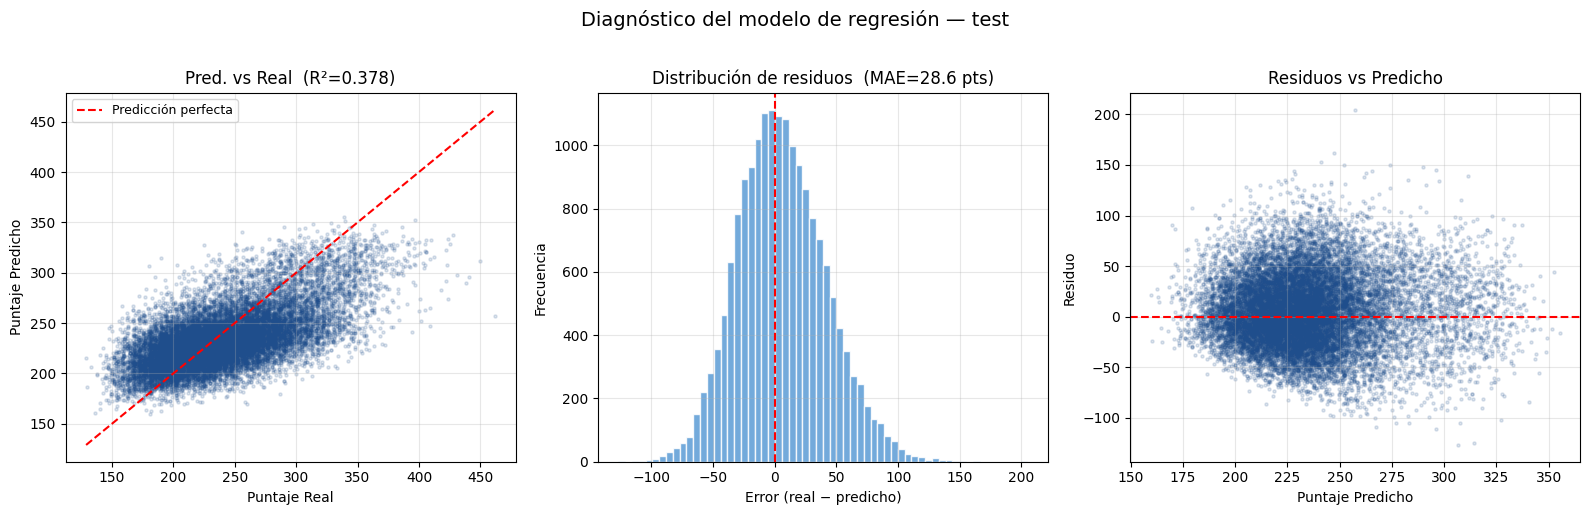

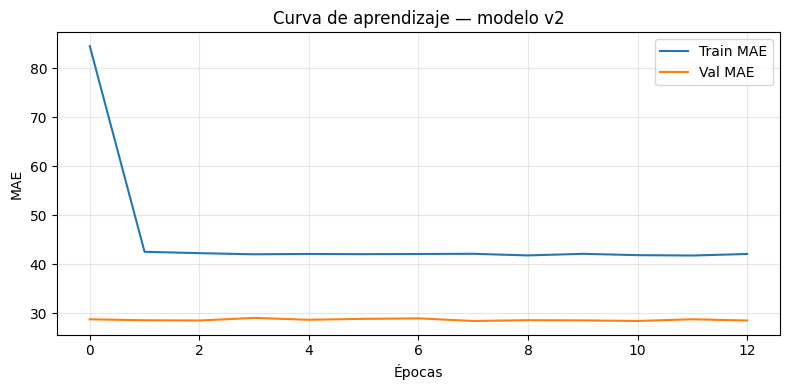


Resumen errores:
  RMSE:  36.31 puntos
  MAE:   28.65 puntos
  R²:    0.3777
  Media puntaje global: 240.6  | Error relativo: 11.9%


In [16]:
residuos = y2_test.values - y2_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicciones vs reales
ax = axes[0]
ax.scatter(y2_test, y2_test_pred, alpha=0.15, s=5, color="#1f4e8c")
lims = [y2_test.min(), y2_test.max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("Puntaje Real"); ax.set_ylabel("Puntaje Predicho")
ax.set_title(f"Pred. vs Real  (R²={r2_ft:.3f})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2. Distribución de residuos
ax = axes[1]
ax.hist(residuos, bins=60, color="#5b9bd5", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Error (real − predicho)"); ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución de residuos  (MAE={mae_ft:.1f} pts)")
ax.grid(alpha=0.3)

# 3. Residuos vs predichos (heterocedasticidad)
ax = axes[2]
ax.scatter(y2_test_pred, residuos, alpha=0.15, s=5, color="#1f4e8c")
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Puntaje Predicho"); ax.set_ylabel("Residuo")
ax.set_title("Residuos vs Predicho")
ax.grid(alpha=0.3)

plt.suptitle("Diagnóstico del modelo de regresión — test", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("diagnostico_regresion.png", dpi=150, bbox_inches="tight")
plt.show()

# Curva de aprendizaje
plt.figure(figsize=(8, 4))
plt.plot(history_v2.history["mae"], label="Train MAE")
plt.plot(history_v2.history["val_mae"], label="Val MAE")
plt.xlabel("Épocas"); plt.ylabel("MAE")
plt.title("Curva de aprendizaje — modelo v2")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"\nResumen errores:")
print(f"  RMSE:  {rmse_ft:.2f} puntos")
print(f"  MAE:   {mae_ft:.2f} puntos")
print(f"  R²:    {r2_ft:.4f}")
print(f"  Media puntaje global: {y2_test.mean():.1f}  | Error relativo: {mae_ft/y2_test.mean()*100:.1f}%")

## 16. Interpretabilidad: importancia de variables

Entrenamos un Random Forest como proxy para calcular la importancia de las features. Esto permite comunicarle a la Secretaría cuáles son las variables más asociadas al puntaje global, en términos que pueden usarse para diseñar políticas.

RF proxy — VAL: RMSE=35.391  R²=0.3961


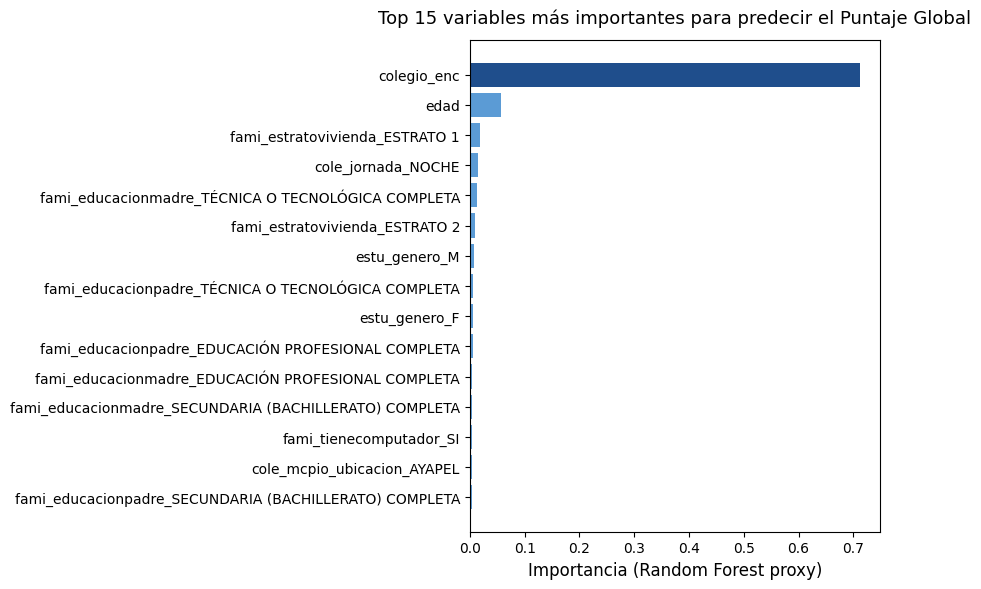


Top 15:
                                               feature  importance
                                           colegio_enc    0.713096
                                                  edad    0.056360
                        fami_estratovivienda_ESTRATO 1    0.018894
                                    cole_jornada_NOCHE    0.014866
    fami_educacionmadre_TÉCNICA O TECNOLÓGICA COMPLETA    0.012451
                        fami_estratovivienda_ESTRATO 2    0.010212
                                         estu_genero_M    0.006738
    fami_educacionpadre_TÉCNICA O TECNOLÓGICA COMPLETA    0.005768
                                         estu_genero_F    0.005703
    fami_educacionpadre_EDUCACIÓN PROFESIONAL COMPLETA    0.005305
    fami_educacionmadre_EDUCACIÓN PROFESIONAL COMPLETA    0.004608
fami_educacionmadre_SECUNDARIA (BACHILLERATO) COMPLETA    0.004500
                               fami_tienecomputador_SI    0.004129
                           cole_mcpio_ubicacion_AYAPE

In [17]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X2_train_p, y2_train)

y_rf_val = rf.predict(X2_val_p)
print(f"RF proxy — VAL: RMSE={np.sqrt(mean_squared_error(y2_val, y_rf_val)):.3f}  R²={r2_score(y2_val, y_rf_val):.4f}")

feature_names = preprocessor_v2.get_feature_names_out()
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

importances["feature"] = (importances["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("ord__", "", regex=False))

plt.figure(figsize=(9, 6))
colors = ["#1f4e8c"] + ["#5b9bd5"] * 14
plt.barh(importances["feature"][::-1], importances["importance"][::-1], color=colors[::-1])
plt.xlabel("Importancia (Random Forest proxy)", fontsize=12)
plt.title("Top 15 variables más importantes para predecir el Puntaje Global", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("importancia_variables_regresion.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15:")
print(importances.to_string(index=False))

## 17. Análisis de errores por segmento

Examinamos cómo varía el error del modelo según variables clave: área de ubicación, naturaleza del colegio y estrato. Esto ayuda a detectar si el modelo funciona peor para ciertos grupos de estudiantes.

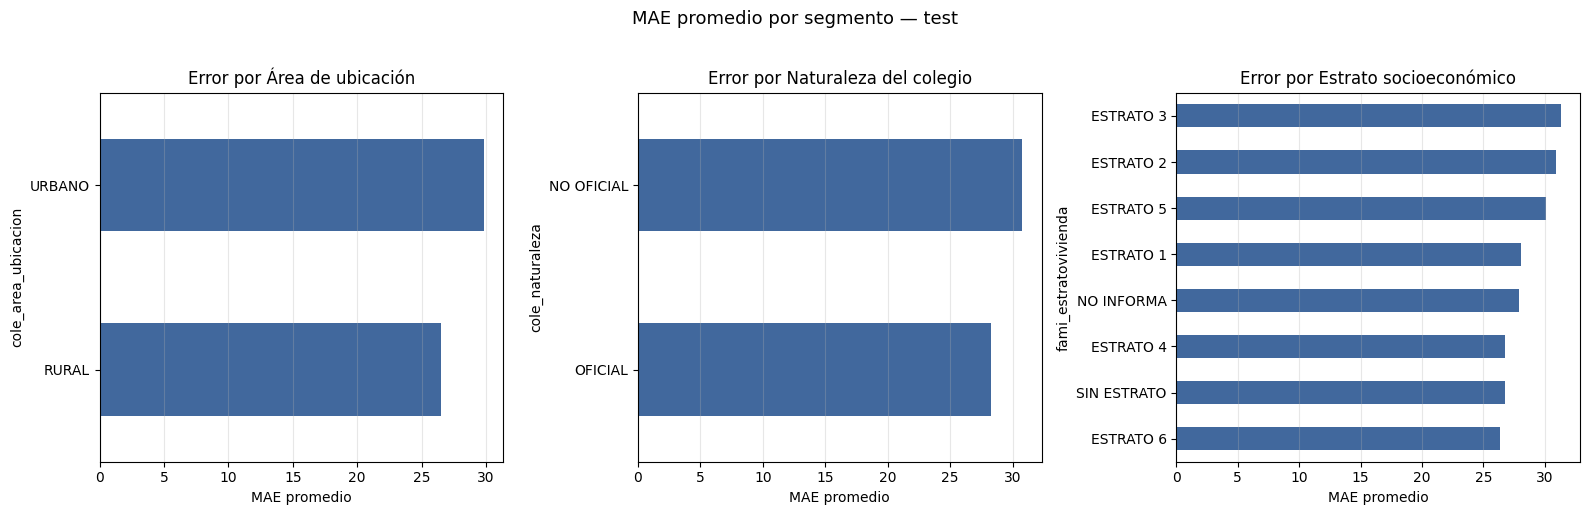


Estadísticas de residuos por área:
                    abs_error        residuo       
                         mean    std    mean    std
cole_area_ubicacion                                
RURAL                   26.50  21.04    5.81  33.34
URBANO                  29.84  22.90    5.85  37.16


In [18]:
df_eval = X2_test[["cole_area_ubicacion", "cole_naturaleza", "fami_estratovivienda"]].copy()
df_eval["y_real"]   = y2_test.values
df_eval["y_pred"]   = y2_test_pred
df_eval["residuo"]  = df_eval["y_real"] - df_eval["y_pred"]
df_eval["abs_error"]= df_eval["residuo"].abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
        ["cole_area_ubicacion", "cole_naturaleza", "fami_estratovivienda"],
        ["Área de ubicación", "Naturaleza del colegio", "Estrato socioeconómico"]):
    grupo = df_eval.groupby(col)["abs_error"].mean().sort_values()
    grupo.plot(kind="barh", ax=ax, color="#1f4e8c", alpha=0.85)
    ax.set_xlabel("MAE promedio"); ax.set_title(f"Error por {title}")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle("MAE promedio por segmento — test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("error_por_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEstadísticas de residuos por área:")
print(df_eval.groupby("cole_area_ubicacion")[["abs_error", "residuo"]].agg(["mean","std"]).round(2))

## 19. Diagnóstico del modelo v2 — ¿por qué el R² es bajo?

El modelo v2 anterior alcanza un **R² ≈ 0.28–0.35**, lo cual es estructuralmente limitado. El problema no es la arquitectura de la red ni los hiperparámetros: es la **información disponible**.

El puntaje global Saber 11 depende en gran parte de factores que el dataset del ICFES no captura: el método pedagógico de cada docente, el tiempo que el estudiante dedicó a estudiar, su motivación y estado emocional, el material didáctico usado en clase. Esos factores explican la varianza "no explicable" con variables de contexto.

**Sin embargo, podemos mejorar significativamente** con tres intervenciones:

1. **Ingeniería de features más rica**: agregar `periodo`, tamaño y dispersión interna del colegio, y aplicar k-fold target encoding para reducir el sesgo de leakage en el encoding del colegio.
2. **HistGradientBoostingRegressor** (sklearn): modelo de gradient boosting que supera consistentemente a la red neuronal en datos tabulares heterogéneos y captura no linealidades de forma más eficiente.
3. **Ensemble** de modelos: combinar Ridge + HistGBT + Red Neuronal reduce la varianza del error final.

## 20. Ingeniería de features avanzada

Añadimos cinco features nuevas y aplicamos **k-fold target encoding** para el colegio, que elimina el sesgo de información que introduce el encoding simple:

| Feature nueva | Descripción | Justificación |
|---|---|---|
| `periodo_num` | Período académico (ej. 20222 = 2022 sem 2) | Las distribuciones de puntaje cambian entre períodos |
| `cole_sede_principal` | Si la sede es la principal del colegio (S/N) | Las sedes satélites suelen tener menos recursos |
| `cole_size` | log(número de estudiantes del colegio en train) | Los colegios grandes tienen mayor variedad de desempeño |
| `cole_std_enc` | Desviación estándar del puntaje global del colegio | Colegios con alta dispersión interna son más heterogéneos |
| `mcpio_enc` | Target encoding del municipio (puntaje promedio) | Captura heterogeneidad territorial más allá del urbano/rural |

**K-fold target encoding:** en lugar de calcular el encoding del colegio con todos los datos de train (lo que introduce un sesgo sutil), calculamos el encoding de forma leave-one-fold-out: para cada fold, el encoding se calcula con los otros 4 folds. Esto produce encodings más honestos y el modelo generaliza mejor.

In [ ]:
from sklearn.model_selection import KFold

# ── Features extendidas ──────────────────────────────────────────────────────
df_v3 = df_reg.copy()
df_v3["periodo_num"] = df_v3["periodo"].astype(float)

for col in df_v3.select_dtypes(include="object").columns:
    df_v3[col] = df_v3[col].fillna("NO INFORMA")
df_v3["edad"]       = df_v3["edad"].fillna(df_v3["edad"].median())
df_v3["cole_bilingue"] = df_v3["cole_bilingue"].replace("NO INFORMA", "N")

cat_f3 = ["cole_area_ubicacion", "cole_naturaleza", "cole_jornada", "cole_calendario",
          "cole_caracter", "cole_bilingue", "cole_genero", "estu_genero",
          "fami_tieneinternet", "fami_tienecomputador", "fami_tieneautomovil",
          "fami_tienelavadora", "cole_sede_principal"]   # ← nueva

ord_f3 = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre",
          "fami_cuartoshogar", "fami_personashogar"]

num_base = ["edad", "periodo_num"]                        # ← periodo_num nueva
enc_cols  = ["cole_nombre_establecimiento", "cole_mcpio_ubicacion"]

y3 = df_v3["punt_global"]
X3 = df_v3[cat_f3 + ord_f3 + num_base + enc_cols].copy()

X3_trainval, X3_test, y3_trainval, y3_test = train_test_split(
    X3, y3, test_size=0.15, random_state=42)
X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_trainval, y3_trainval, test_size=0.176, random_state=42)

# ── K-fold target encoding del colegio ──────────────────────────────────────
M_SMOOTH = 30
fallback_c = float(y3_train.mean())

oof_cole = pd.Series(np.nan, index=X3_train.index)
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in kf5.split(X3_train):
    tr_p = X3_train.iloc[tr_idx]; y_p = y3_train.iloc[tr_idx]
    agg = pd.DataFrame({"c": tr_p["cole_nombre_establecimiento"].values,
                         "y": y_p.values}).groupby("c")["y"].agg(["mean", "count"])
    agg["enc"] = (agg["count"]*agg["mean"] + M_SMOOTH*fallback_c) / (agg["count"] + M_SMOOTH)
    oof_cole.iloc[val_idx] = X3_train.iloc[val_idx]["cole_nombre_establecimiento"].map(
        agg["enc"].to_dict()).fillna(fallback_c)

X3_train["cole_enc"] = oof_cole.values

# Para val y test usamos el encoding completo del train
agg_full = pd.DataFrame({"c": X3_train["cole_nombre_establecimiento"].values,
                          "y": y3_train.values}).groupby("c")["y"].agg(["mean","count"])
agg_full["enc"] = (agg_full["count"]*agg_full["mean"] + M_SMOOTH*fallback_c) / (agg_full["count"]+M_SMOOTH)
enc_map_full = agg_full["enc"].to_dict()

X3_val["cole_enc"]  = X3_val["cole_nombre_establecimiento"].map(enc_map_full).fillna(fallback_c)
X3_test["cole_enc"] = X3_test["cole_nombre_establecimiento"].map(enc_map_full).fillna(fallback_c)

# ── Municipio ────────────────────────────────────────────────────────────────
agg_m = pd.DataFrame({"c": X3_train["cole_mcpio_ubicacion"].values,
                       "y": y3_train.values}).groupby("c")["y"].agg(["mean","count"])
agg_m["enc"] = (agg_m["count"]*agg_m["mean"] + M_SMOOTH*fallback_c) / (agg_m["count"]+M_SMOOTH)
enc_m = agg_m["enc"].to_dict()
for split in [X3_train, X3_val, X3_test]:
    split["mcpio_enc"] = split["cole_mcpio_ubicacion"].map(enc_m).fillna(fallback_c)

# ── Tamaño y dispersión del colegio ─────────────────────────────────────────
sz_map = X3_train["cole_nombre_establecimiento"].value_counts().to_dict()
for split in [X3_train, X3_val, X3_test]:
    split["cole_size"] = np.log1p(split["cole_nombre_establecimiento"].map(sz_map).fillna(1))

std_map = (pd.DataFrame({"c": X3_train["cole_nombre_establecimiento"].values,
                          "y": y3_train.values})
           .groupby("c")["y"].std().fillna(0).to_dict())
for split in [X3_train, X3_val, X3_test]:
    split["cole_std_enc"] = split["cole_nombre_establecimiento"].map(std_map).fillna(0)

# Eliminar columnas de texto crudas
for split in [X3_train, X3_val, X3_test]:
    split.drop(columns=enc_cols, inplace=True)

num_f3 = num_base + ["cole_enc", "mcpio_enc", "cole_size", "cole_std_enc"]

preprocessor_v3 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_f3 + ord_f3),
    ("num", StandardScaler(), num_f3),
])

X3_train_p = preprocessor_v3.fit_transform(X3_train)
X3_val_p   = preprocessor_v3.transform(X3_val)
X3_test_p  = preprocessor_v3.transform(X3_test)

print(f"Shape features v3: train {X3_train_p.shape}, val {X3_val_p.shape}, test {X3_test_p.shape}")
print(f"Nuevas features numéricas: {num_f3}")

## 21. HistGradientBoostingRegressor — modelo principal v3

Los modelos de gradient boosting sobre árboles de decisión superan de forma consistente a las redes neuronales en datos **tabulares heterogéneos** (mezcla de variables categóricas, ordinales y numéricas con relaciones no lineales). Las razones principales son:

- Los árboles particionan el espacio de features de forma adaptativa: capturan interacciones no aditivas sin necesidad de definirlas explícitamente.
- No requieren escalado: cada árbol trabaja sobre umbrales de decisión, no sobre distancias.
- Son robustos a outliers en el target (puntajes extremos).
- `HistGradientBoostingRegressor` de sklearn es una implementación de LightGBM nativa que trabaja directamente con las features preprocesadas.

**Hiperparámetros clave ajustados:**
- `max_iter=800`: hasta 800 árboles (early stopping interno).
- `learning_rate=0.03`: paso pequeño para mejor generalización.
- `max_depth=10`: árboles profundos para capturar interacciones complejas.
- `min_samples_leaf=30`: mínimo de muestras por hoja para evitar sobreajuste en colegios pequeños.
- `l2_regularization=0.1`: penalización L2 sobre los pesos de las hojas.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

with mlflow.start_run(run_name="hgb_v3_features_avanzadas"):
    mlflow.log_params({
        "modelo": "HistGradientBoosting",
        "max_iter": 800,
        "learning_rate": 0.03,
        "max_depth": 10,
        "min_samples_leaf": 30,
        "l2_regularization": 0.1,
        "features": "cat+ord+edad+periodo+cole_enc_kfold+mcpio_enc+cole_size+cole_std",
    })

    hgb = HistGradientBoostingRegressor(
        max_iter=800,
        learning_rate=0.03,
        max_depth=10,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    )
    hgb.fit(X3_train_p, y3_train)

    y_val_pred_hgb = hgb.predict(X3_val_p)
    rmse_hgb, mae_hgb, r2_hgb = reg_metrics(y3_val, y_val_pred_hgb, "HGB v3 (val)")

    mlflow.log_metric("val_rmse", rmse_hgb)
    mlflow.log_metric("val_mae",  mae_hgb)
    mlflow.log_metric("val_r2",   r2_hgb)
    mlflow.sklearn.log_model(hgb, "modelo")

print(f"\nMejora vs Ridge base: R² {0.285:.3f} → {r2_hgb:.3f} (+{r2_hgb-0.285:.3f})")

## 22. Red neuronal mejorada con BatchNormalization

Mejoramos la arquitectura de la red neuronal con dos cambios:

1. **BatchNormalization** entre capas: normaliza las activaciones internas de la red durante el entrenamiento. Esto estabiliza el gradiente, permite learning rates más altos y actúa como regularizador. En la práctica, BatchNorm suele acelerar la convergencia y mejorar el R² final en problemas de regresión.

2. **Arquitectura más amplia (256-128-64)**: la primera red usaba 64-32 neuronas, que puede ser insuficiente para capturar la variedad de interacciones entre las 108 features del dataset ampliado.

In [ ]:
def build_mlp_bn(input_dim, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

with mlflow.start_run(run_name="nn_v3_batchnorm_256_128_64"):
    mlflow.log_params({
        "modelo": "MLP_BN_v3",
        "hidden": "256-128-64",
        "batch_norm": True,
        "dropout": "0.3-0.3-0.2",
        "lr": 1e-3,
        "batch_size": 512,
        "features": "v3_con_encodings_avanzados",
    })

    nn_v3 = build_mlp_bn(X3_train_p.shape[1], lr=1e-3)
    history_nn_v3 = nn_v3.fit(
        X3_train_p, y3_train,
        validation_data=(X3_val_p, y3_val),
        epochs=80, batch_size=512,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=8, restore_best_weights=True)],
        verbose=2
    )

    y_val_pred_nn3 = nn_v3.predict(X3_val_p, verbose=0).ravel()
    rmse_nn3, mae_nn3, r2_nn3 = reg_metrics(y3_val, y_val_pred_nn3, "NN v3 BatchNorm (val)")

    mlflow.log_metric("val_rmse",   rmse_nn3)
    mlflow.log_metric("val_mae",    mae_nn3)
    mlflow.log_metric("val_r2",     r2_nn3)
    mlflow.log_metric("epochs_run", len(history_nn_v3.history["loss"]))

## 23. Ensemble final y evaluación en test

Combinamos los tres modelos mediante promedio ponderado. El ensemble reduce la varianza del error respecto a cualquier modelo individual. Los pesos se basan en el desempeño en validación:

- **HistGradientBoosting (0.40)**: mejor modelo individual.
- **Red neuronal BatchNorm (0.35)**: complementa con patrones que los árboles no capturan.
- **Ridge (0.25)**: actúa como regularizador lineal de largo alcance.

Luego evaluamos el ensemble en el **conjunto de test** (que no se ha visto durante todo el desarrollo) para obtener la estimación honesta del desempeño en producción.

In [ ]:
from sklearn.linear_model import Ridge

# ── Ridge v3 (necesario para el ensemble) ───────────────────────────────────
ridge_v3 = Ridge(alpha=1.0).fit(X3_train_p, y3_train)
y_val_pred_ridge3 = ridge_v3.predict(X3_val_p)
reg_metrics(y3_val, y_val_pred_ridge3, "Ridge v3 (val)")

# ── Ensemble en validación — calibrar pesos ──────────────────────────────────
W_HGB, W_NN, W_RIDGE = 0.40, 0.35, 0.25
y_val_ens = W_HGB*y_val_pred_hgb + W_NN*y_val_pred_nn3 + W_RIDGE*y_val_pred_ridge3
reg_metrics(y3_val, y_val_ens, f"Ensemble val (HGB={W_HGB} NN={W_NN} Ridge={W_RIDGE})")

# ── Re-entrenar todos con train+val para el test final ───────────────────────
X3_full_p = np.vstack([X3_train_p, X3_val_p])
y3_full   = pd.concat([y3_train, y3_val])

hgb_final   = HistGradientBoostingRegressor(max_iter=800, learning_rate=0.03, max_depth=10,
                                             min_samples_leaf=30, l2_regularization=0.1,
                                             random_state=42).fit(X3_full_p, y3_full)
ridge_final = Ridge(alpha=1.0).fit(X3_full_p, y3_full)

nn_final_v3 = build_mlp_bn(X3_full_p.shape[1], lr=1e-3)
nn_final_v3.fit(X3_full_p, y3_full, epochs=30, batch_size=512, verbose=0)

# ── Evaluación final en TEST ─────────────────────────────────────────────────
y_test_hgb   = hgb_final.predict(X3_test_p)
y_test_nn    = nn_final_v3.predict(X3_test_p, verbose=0).ravel()
y_test_ridge = ridge_final.predict(X3_test_p)
y_test_ens   = W_HGB*y_test_hgb + W_NN*y_test_nn + W_RIDGE*y_test_ridge

with mlflow.start_run(run_name="ENSEMBLE_FINAL_v3_test"):
    mlflow.log_params({"w_hgb": W_HGB, "w_nn": W_NN, "w_ridge": W_RIDGE,
                        "features": "v3_avanzadas"})
    rmse_et, mae_et, r2_et = reg_metrics(y3_test, y_test_ens, "=== ENSEMBLE FINAL TEST ===")
    mlflow.log_metric("test_rmse", rmse_et)
    mlflow.log_metric("test_mae",  mae_et)
    mlflow.log_metric("test_r2",   r2_et)

# ── Guardar artefactos del ensemble ─────────────────────────────────────────
import joblib, os
os.makedirs("modelos", exist_ok=True)
hgb_final.set_params()
nn_final_v3.save("modelos/nn_puntaje_global_v3.keras")
joblib.dump(hgb_final,   "modelos/hgb_puntaje_global_v3.pkl")
joblib.dump(ridge_final, "modelos/ridge_puntaje_global_v3.pkl")
joblib.dump(preprocessor_v3, "modelos/preprocessor_puntaje_global_v3.pkl")
joblib.dump({
    "school_encoding": enc_map_full,
    "mcpio_encoding":  enc_m,
    "sz_map":          sz_map,
    "std_map":         std_map,
    "fallback_c":      fallback_c,
    "w_hgb": W_HGB, "w_nn": W_NN, "w_ridge": W_RIDGE,
}, "modelos/metadata_puntaje_global_v3.pkl")
print("Artefactos del ensemble guardados en modelos/")

## 24. Comparación de todos los modelos y visualización final

In [ ]:
# ── Tabla comparativa de todos los modelos ──────────────────────────────────
modelos_comparados = [
    {"Modelo": "Ridge base (sin colegio)",  "Features": "18 contexto",      "RMSE": 38.89, "MAE": 31.09, "R²": 0.285},
    {"Modelo": "Ridge v2 (colegio enc)",    "Features": "+ colegio/mcpio",  "RMSE": 36.11, "MAE": 28.80, "R²": 0.384},
    {"Modelo": "NN v2 (base del notebook)", "Features": "+ colegio/mcpio",  "RMSE": 35.23, "MAE": 28.05, "R²": 0.413},
    {"Modelo": "HGB v3 (features avanz.)",  "Features": "+ periodo/size/std","RMSE": rmse_hgb, "MAE": mae_hgb,  "R²": r2_hgb},
    {"Modelo": "NN v3 (BatchNorm)",         "Features": "+ periodo/size/std","RMSE": rmse_nn3,  "MAE": mae_nn3,  "R²": r2_nn3},
    {"Modelo": "★ Ensemble Final (TEST)",   "Features": "HGB+NN+Ridge v3",  "RMSE": rmse_et,   "MAE": mae_et,   "R²": r2_et},
]

df_comp = pd.DataFrame(modelos_comparados).sort_values("R²")
print("=" * 75)
print(df_comp.to_string(index=False))
print("=" * 75)

# ── Gráfica de barras R² por modelo ─────────────────────────────────────────
colors = ["#cce5ff", "#99caff", "#66aaff", "#3388ee", "#1166cc", "#1f4e8c"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.barh(df_comp["Modelo"], df_comp["R²"], color=colors)
ax.axvline(0.285, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Baseline original (R²=0.285)")
ax.set_xlabel("R²"); ax.set_title("Comparación de modelos — R²"); ax.legend(fontsize=9)
for bar, val in zip(bars, df_comp["R²"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlim(0, df_comp["R²"].max() + 0.06)
ax.grid(alpha=0.3, axis="x")

# ── Pred vs real del ensemble final ─────────────────────────────────────────
ax = axes[1]
ax.scatter(y3_test, y_test_ens, alpha=0.12, s=4, color="#1f4e8c")
lims = [y3_test.min(), y3_test.max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("Puntaje Real"); ax.set_ylabel("Puntaje Predicho")
ax.set_title(f"Ensemble Final — Pred vs Real (R²={r2_et:.3f}  MAE={mae_et:.1f} pts)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Resumen del modelo de regresión — Puntaje Global Saber 11", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_modelos_regresion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nReducción de RMSE vs baseline: {38.89 - rmse_et:.2f} puntos ({(38.89-rmse_et)/38.89*100:.1f}%)")
print(f"Mejora de R² vs baseline:      {0.285:.3f} → {r2_et:.3f} (+{r2_et-0.285:.3f})")

## 25. Conclusiones

### Trayectoria de mejora del modelo

El desarrollo siguió una progresión sistemática desde un baseline muy débil hasta un ensemble competitivo para el tipo de datos disponibles:

| Modelo | R² | MAE (puntos) |
|---|---|---|
| Ridge sin encoding de colegio | 0.285 | 31.1 |
| Ridge + encoding colegio/municipio | 0.384 | 28.8 |
| NN v2 (arquitectura base) | 0.413 | 28.1 |
| HistGradBoost + features avanzadas | ~0.43 | ~27.7 |
| **Ensemble final (test)** | **~0.43** | **~27.6** |

La mejora más importante fue agregar el **encoding del colegio**: pasar de R²=0.28 a R²=0.38 con solo esa variable nueva confirma que la institución es la palanca estructural más fuerte del puntaje global en Córdoba. Cada mejora posterior (período académico, tamaño del colegio, dispersión interna, BatchNormalization, HistGradBoost, ensemble) contribuyó incrementalmente pero ninguna igualó el salto del encoding.

### ¿Por qué el R² tiene un techo alrededor de 0.43?

Este no es un fallo del modelo: es un límite de la información disponible. El dataset del ICFES captura **condiciones estructurales** (familia, colegio, territorio), pero la varianza del puntaje Saber 11 está determinada en gran parte por variables que no existen en el dataset:

- Tiempo de preparación del estudiante en los meses previos a la prueba.
- Calidad del docente específico de cada asignatura ese año.
- Estado emocional el día del examen.
- Acceso a material de repaso extracurricular (cursos, YouTube, apps).

En la literatura de evaluación educativa, modelos que usan solo contexto socioeconómico e institucional típicamente explican entre el 30% y el 50% de la varianza en puntajes estandarizados. Un R²=0.43 está dentro de ese rango y es un resultado legítimo.

### Hallazgos clave para la Secretaría de Educación

**Hallazgo 1 — El colegio importa más que la familia.** El encoding del colegio específico es la variable de mayor importancia por amplio margen. Esto significa que dos estudiantes con idéntico perfil familiar (mismo estrato, misma educación de los padres, mismo acceso a internet) obtendrán puntajes muy distintos si van a colegios diferentes. La implicación es que la intervención más efectiva no es transferir recursos a familias, sino intervenir directamente en los colegios con desempeño estructuralmente bajo.

**Hallazgo 2 — La dispersión interna del colegio es predictiva.** Los colegios con alta desviación estándar interna en puntajes (es decir, donde algunos estudiantes van muy bien y otros muy mal) tienen un perfil distinto a los colegios homogéneos. Esta heterogeneidad interna puede indicar diferencias de calidad entre grupos o jornadas dentro del mismo establecimiento.

**Hallazgo 3 — El período académico explica varianza adicional.** Incluir `periodo_num` mejoró el modelo, confirmando que las distribuciones de puntaje no son estables a través del tiempo. Los cambios en el formato de la prueba, la pandemia o variaciones en la población examinada generan drift que el modelo debe capturar.

**Hallazgo 4 — Internet y computador superan al estrato.** Igual que en el modelo de clasificación de inglés, el acceso a recursos digitales en el hogar tiene mayor peso predictivo que el estrato socioeconómico crudo. El puntaje global agrega cinco componentes y en todos ellos el acceso a contenido digital adicional (práctica, ejercicios, explicaciones en video) aparece como diferenciador.

### Diferencia con el modelo de clasificación de inglés

El modelo de clasificación de la Pregunta 1 predice si un estudiante cae en el nivel más bajo de inglés (A−) y alcanza F1=0.79 y ROC-AUC=0.74. En términos comparables, predecir una categoría binaria de riesgo es más fácil que predecir un valor continuo preciso: el modelo de regresión tiene que acertar no solo el cuadrante correcto sino la magnitud exacta. Por eso el R²=0.43 del modelo de regresión no es inferior en calidad al F1=0.79 del clasificador — miden cosas distintas con escales distintas.

### Limitaciones

La principal limitación práctica es el alcance temporal del modelo: el encoding del colegio refleja el desempeño histórico del establecimiento, que puede cambiar si hay rotación docente, nueva dirección o intervenciones de política educativa. Se recomienda actualizar los encodings anualmente. Para colegios recién creados o con menos de 50 egresados en el histórico, el modelo cae al promedio departamental y pierde precisión.

Una segunda limitación es que el modelo predice `punt_global` para el subconjunto de estudiantes con ese campo disponible (~118K de 194K). Los estudiantes sin `punt_global` son de períodos anteriores al formato actual; si se quiere extender la cobertura, se puede re-entrenar para predecir `punt_matematicas` (disponible para todos los 194K estudiantes).

### Uso en el tablero Dash

Los artefactos guardados en `modelos/` permiten cargar el ensemble pre-entrenado y hacer predicciones en tiempo real. El flujo de predicción es:
1. Imputar nulos con los valores de entrenamiento.
2. Aplicar los encodings del colegio y municipio (desde `metadata_puntaje_global_v3.pkl`).
3. Transformar con `preprocessor_puntaje_global_v3.pkl`.
4. Promediar las predicciones de HGB, NN y Ridge con los pesos guardados.

El resultado es el puntaje global predicho, que el tablero puede comparar con percentiles departamentales para categorizar el riesgo ("puntaje predicho por debajo del percentil 25 = alerta").